In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Data Preparation

# 1. Reading Data

## 1.1 Reading Data

In [2]:
excel_file_name = 'buying_Prices_Final_Raw_With_VS30_isimDuzenlenmis.xlsx'
csv_file_name = 'buying_Prices_Final_Raw_With_VS30_isimDuzenlenmis.csv'

# Use a try-except block to handle potential errors, like the file not being found.
try:
    df = pd.read_excel(excel_file_name)

    #print(df.head())

    # The 'index=False' argument prevents pandas from writing the DataFrame index to the CSV.
    #df.to_csv(csv_file_name, index=False)

    print(f"\nSuccessfully read '{excel_file_name}' and saved the data as '{csv_file_name}'.")

except FileNotFoundError:
    print(f"Error: The file '{excel_file_name}' was not found. Please check the file name and path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Successfully read 'buying_Prices_Final_Raw_With_VS30_isimDuzenlenmis.xlsx' and saved the data as 'buying_Prices_Final_Raw_With_VS30_isimDuzenlenmis.csv'.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9204 entries, 0 to 9203
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Fiyat               9204 non-null   object 
 1   Lokasyon            9204 non-null   object 
 2   Link                9204 non-null   object 
 3   İlan no             9204 non-null   object 
 4   Son Güncelleme      9204 non-null   object 
 5   İlan Durumu         9204 non-null   object 
 6   Konut Tipi          9204 non-null   object 
 7   Konut Şekli         5159 non-null   object 
 8   Oda Sayısı          9204 non-null   object 
 9   Banyo Sayısı        9074 non-null   float64
 10  Brüt / Net M2       9204 non-null   object 
 11  Kat Sayısı          9204 non-null   object 
 12  Bulunduğu Kat       8786 non-null   object 
 13  Bina Yaşı           9204 non-null   object 
 14  Isınma Tipi         9204 non-null   object 
 15  Yakıt Tipi          5170 non-null   object 
 16  Krediy

## 1.2 Changing Column Names

In [4]:
# Sütun isimlerini İngilizce'ye çevirme
df = df.rename(columns={
    'Fiyat': 'Price',
    'Lokasyon': 'Location',
    'Link': 'Link',
    'İlan no': 'Ad_No',
    'Son Güncelleme': 'Last_Update',
    'İlan Durumu': 'Ad_Status',
    'Konut Tipi': 'Housing_Type',
    'Konut Şekli': 'Housing_Form',
    'Oda Sayısı': 'Total_Room',
    'Banyo Sayısı': 'Bathroom_Count',
    'Brüt / Net M2': 'Net_M2',
    'Kat Sayısı': 'Number_of_Floors',
    'Bulunduğu Kat': 'Floor',
    'Bina Yaşı': 'Building_Age',
    'Isınma Tipi': 'Heating_Type',
    'Yakıt Tipi': 'Fuel_Type',
    'Krediye Uygunlu...': 'Loan_Eligibilit...',
    'Tapu Durumu': 'Deed_Status',
    'Eşya Durumu': 'Furnished_Status',
    'Yapı Tipi': 'Building_Type',
    'Yapının Durumu': 'Is_New_Building',
    'Kullanım Durumu': 'Occupancy_Status',
    'Cephe': 'Facade',
    'Takas': 'Swap',
    'Kira Getirisi': 'Rental_Income',
    'Aidat': 'Dues',
    'Yetkili Ofis': 'Authorized_Office',
    'Site İçerisinde': 'In_a_Complex',
    'Krediye Uygunluk': 'Loan_Eligibility',
    'Depozito': 'Deposit'
})

print(df.columns)

Index(['Price', 'Location', 'Link', 'Ad_No', 'Last_Update', 'Ad_Status',
       'Housing_Type', 'Housing_Form', 'Total_Room', 'Bathroom_Count',
       'Net_M2', 'Number_of_Floors', 'Floor', 'Building_Age', 'Heating_Type',
       'Fuel_Type', 'Loan_Eligibilit...', 'Deed_Status', 'Furnished_Status',
       'Building_Type', 'Is_New_Building', 'Occupancy_Status', 'Facade',
       'Swap', 'Rental_Income', 'Dues', 'Authorized_Office', 'In_a_Complex',
       'Loan_Eligibility', 'Deposit', 'Vs30'],
      dtype='object')


In [5]:
df2 = df

# 2. Cleaning Data

## 2.1 Deleting Unnecessary Columns (DF2)

In [6]:
df2.isnull().sum()

Price                    0
Location                 0
Link                     0
Ad_No                    0
Last_Update              0
Ad_Status                0
Housing_Type             0
Housing_Form          4045
Total_Room               0
Bathroom_Count         130
Net_M2                   0
Number_of_Floors         0
Floor                  418
Building_Age             0
Heating_Type             0
Fuel_Type             4034
Loan_Eligibilit...    6863
Deed_Status              4
Furnished_Status       507
Building_Type         4320
Is_New_Building       4146
Occupancy_Status       271
Facade                1608
Swap                   679
Rental_Income         6646
Dues                  5818
Authorized_Office     4742
In_a_Complex          7232
Loan_Eligibility         0
Deposit               9203
Vs30                     0
dtype: int64

In [7]:
# Deleting columns 
columns_to_drop = ['Link', "Ad_No", 'Last_Update', "Ad_Status", "Housing_Form", "Fuel_Type", "Loan_Eligibilit...", "Rental_Income", "Authorized_Office", "Deposit", "Facade", "Dues", "Authorized_Office"]
df2 = df.drop(columns=columns_to_drop)

In [8]:
df2.isnull().sum()

Price                  0
Location               0
Housing_Type           0
Total_Room             0
Bathroom_Count       130
Net_M2                 0
Number_of_Floors       0
Floor                418
Building_Age           0
Heating_Type           0
Deed_Status            4
Furnished_Status     507
Building_Type       4320
Is_New_Building     4146
Occupancy_Status     271
Swap                 679
In_a_Complex        7232
Loan_Eligibility       0
Vs30                   0
dtype: int64

In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9204 entries, 0 to 9203
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             9204 non-null   object 
 1   Location          9204 non-null   object 
 2   Housing_Type      9204 non-null   object 
 3   Total_Room        9204 non-null   object 
 4   Bathroom_Count    9074 non-null   float64
 5   Net_M2            9204 non-null   object 
 6   Number_of_Floors  9204 non-null   object 
 7   Floor             8786 non-null   object 
 8   Building_Age      9204 non-null   object 
 9   Heating_Type      9204 non-null   object 
 10  Deed_Status       9200 non-null   object 
 11  Furnished_Status  8697 non-null   object 
 12  Building_Type     4884 non-null   object 
 13  Is_New_Building   5058 non-null   object 
 14  Occupancy_Status  8933 non-null   object 
 15  Swap              8525 non-null   object 
 16  In_a_Complex      1972 non-null   object 


## 2.2 Cleaning Dublicates Values (DF2)

In [10]:
# Deleting dublicates 
df2 = df2.drop_duplicates()

print(f"Row count before delete dublicate: {len(df)}")
print(f"Row count after delete dublicate: {len(df2)}")

Row count before delete dublicate: 9204
Row count after delete dublicate: 7512


In [11]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7512 entries, 0 to 9203
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             7512 non-null   object 
 1   Location          7512 non-null   object 
 2   Housing_Type      7512 non-null   object 
 3   Total_Room        7512 non-null   object 
 4   Bathroom_Count    7406 non-null   float64
 5   Net_M2            7512 non-null   object 
 6   Number_of_Floors  7512 non-null   object 
 7   Floor             7164 non-null   object 
 8   Building_Age      7512 non-null   object 
 9   Heating_Type      7512 non-null   object 
 10  Deed_Status       7510 non-null   object 
 11  Furnished_Status  7100 non-null   object 
 12  Building_Type     3930 non-null   object 
 13  Is_New_Building   4095 non-null   object 
 14  Occupancy_Status  7286 non-null   object 
 15  Swap              6978 non-null   object 
 16  In_a_Complex      1668 non-null   object 
 17  

In [12]:
#df2.reset_index()

In [13]:
df3 = df2

# 3. Cleaning Column by Column (DF3)

## 3.1 "Price" Column

In [14]:
df3['Price'] = df3['Price'].str.replace(' TL', '', regex=False)

df3['Price'] = df3['Price'].str.replace('.', '', regex=False)

df3['Price'] = df3['Price'].str.strip()

df3['Price'] = pd.to_numeric(df3['Price'])

### 3.1.2 Cleaning "Price" Outlier

In [15]:
df3 = df3[(df3['Price'] >= 800000) & (df3['Price'] <= 200000000)]

### 3.1.3 Creating "Price per M2" and Cleaning Outlier

In [16]:
df32 = df3

## 3.2 "Housing_Type" Column (DF32)

### 3.2.1 Gruoping values

In [17]:
df32.Housing_Type.unique()

array(['Daire', 'Bina', 'Residence', 'Müstakil Ev', 'Villa', 'Yazlık',
       'Köşk', 'Yalı Dairesi', 'Köy Evi', 'Kooperatif', 'Çiftlik Evi'],
      dtype=object)

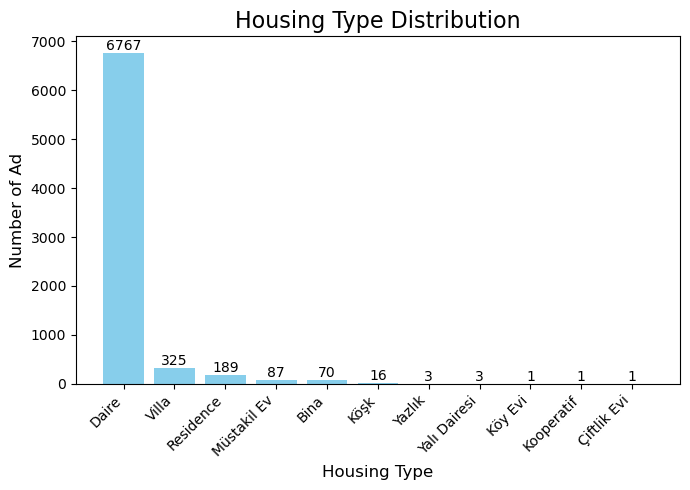

In [18]:
# 'Housing_Type' sütunundaki her bir değerin frekansını (sayısını) hesapla
housing_type_counts = df32['Housing_Type'].value_counts()

plt.figure(figsize=(7, 5))
bars = plt.bar(housing_type_counts.index, housing_type_counts.values, color='skyblue')

# Türkçe karakterlerin düzgün görüntülenmesi için (bazı sistemlerde gerekebilir)
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Grafik başlıkları ve etiketleri
plt.title('Housing Type Distribution', fontsize=16)
plt.xlabel('Housing Type', fontsize=12)
plt.ylabel('Number of Ad', fontsize=12)

# X eksenindeki etiketlerin okunabilirliğini artırmak için 45 derece döndür
plt.xticks(rotation=45, ha='right')

# Barların üzerine değerlerini yazdır
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center') # Değerleri tam sayı olarak yazdır

# Grafiğin kenar boşluklarını ayarla
plt.tight_layout()
plt.show()

In [19]:
#df32['Housing_Type'] = df32['Housing_Type'].replace('Bina', 'Daire')
df32['Housing_Type'] = df32['Housing_Type'].replace('Residence', 'Daire')

df32['Housing_Type'] = df32['Housing_Type'].replace('Müstakil', 'Mustakil')
df32['Housing_Type'] = df32['Housing_Type'].replace('Müstakil Ev', 'Mustakil')
df32['Housing_Type'] = df32['Housing_Type'].replace('Villa', 'Mustakil')
df32['Housing_Type'] = df32['Housing_Type'].replace('Köşk', 'Mustakil')
df32['Housing_Type'] = df32['Housing_Type'].replace('Yazlık', 'Mustakil')
df32['Housing_Type'] = df32['Housing_Type'].replace('Çiftlik Evi', 'Mustakil')
df32['Housing_Type'] = df32['Housing_Type'].replace('Köy Evi', 'Mustakil')

df32['Housing_Type'] = df32['Housing_Type'].replace('Yalı', 'Yali')
df32['Housing_Type'] = df32['Housing_Type'].replace('Yalı Dairesi', 'Yali')

print(df32['Housing_Type'].value_counts())

Housing_Type
Daire         6956
Mustakil       433
Bina            70
Yali             3
Kooperatif       1
Name: count, dtype: int64


C:\Users\emir\AppData\Local\Temp\ipykernel_17692\3181644897.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df32['Housing_Type'] = df32['Housing_Type'].replace('Residence', 'Daire')
C:\Users\emir\AppData\Local\Temp\ipykernel_17692\3181644897.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df32['Housing_Type'] = df32['Housing_Type'].replace('Müstakil', 'Mustakil')
C:\Users\emir\AppData\Local\Temp\ipykernel_17692\3181644897.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

### 3.2.2 One Hot Encoding

In [20]:
# One-Hot Encoding uygulama
df32_encoded = pd.get_dummies(
    df32, 
    columns=['Housing_Type'], 
    prefix='KonutTipi', # Yeni sütunların başına anlamlı bir ön ek koyar
    dtype=int         # Yeni sütunların veri tipini integer (0/1) yapar
)

In [21]:
df32_encoded.columns

Index(['Price', 'Location', 'Total_Room', 'Bathroom_Count', 'Net_M2',
       'Number_of_Floors', 'Floor', 'Building_Age', 'Heating_Type',
       'Deed_Status', 'Furnished_Status', 'Building_Type', 'Is_New_Building',
       'Occupancy_Status', 'Swap', 'In_a_Complex', 'Loan_Eligibility', 'Vs30',
       'KonutTipi_Bina', 'KonutTipi_Daire', 'KonutTipi_Kooperatif',
       'KonutTipi_Mustakil', 'KonutTipi_Yali'],
      dtype='object')

In [22]:
df33 = df32_encoded.copy()

## 3.3 "Total_Room" Column (DF33)

### 3.3.1 Changing room format

In [23]:
# Check null values
df33.Total_Room.isnull().sum()

0

In [24]:
df33.Total_Room.unique()

array(['2 + 1', '3 + 1', '4 + 1', '3 + 2', '1 + 1', '4 + 2', '6 + 1',
       '1 + 0', '5 + 3', '5 + 2', '2 + 0', '8 + 2', '6 + 2', '8 + 1',
       '7 + 2', '5 + 1', '130 + 0', '3 + 0', '10 + 0', '4 + 0', '2 + 2',
       '7 + 1', '7 + 0', '10 + 3', '8 + 3', '6 + 0', '20 + 1', '14 + 4',
       '12 + 4', '12 + 5', '7 + 6', '24 + 1', '7 + 7', '9 + 3', '3 + 3',
       '10 + 4', '5 + 4', '5 + 0', '4 + 3', '6 + 3', '450 + 3', '8 + 4',
       '4 + 12', '9 + 1', '3 + 4', '3 + 11', '4 + 11', '5 + 5', '2 + 10',
       '12 + 0', '4 + 4', '2 + 4', '3 + 10', '7 + 3', '19 + 5', '1 + 2',
       '6 + 6', '63 + 21', '12 + 3', '10 + 2', '7 + 4', '9 + 2', '10 + 5',
       '20 + 5', '6 + 4', '16 + 4'], dtype=object)

In [25]:
print(df33['Total_Room'].value_counts())

Total_Room
2 + 1      2940
3 + 1      2239
1 + 1       643
4 + 1       504
4 + 2       269
           ... 
4 + 12        1
450 + 3       1
7 + 6         1
24 + 1        1
16 + 4        1
Name: count, Length: 66, dtype: int64


In [26]:
# Rooms number turning to total rooms count
def sum_rooms(value):
    try:
        numbers = [int(x) for x in str(value).split("+") if x.strip().isdigit()]
        return sum(numbers) if numbers else None
    except:
        return None

df33["Total_Room"] = df33["Total_Room"].apply(sum_rooms)
print(df33['Total_Room'].value_counts())

Total_Room
3      2969
4      2294
2       684
5       661
6       420
7       215
8        89
9        37
1        35
10       15
12       10
11        7
13        5
14        4
15        4
16        3
17        2
25        2
21        1
18        1
130       1
453       1
24        1
84        1
20        1
Name: count, dtype: int64


### 3.3.2 Outlier Cleaning

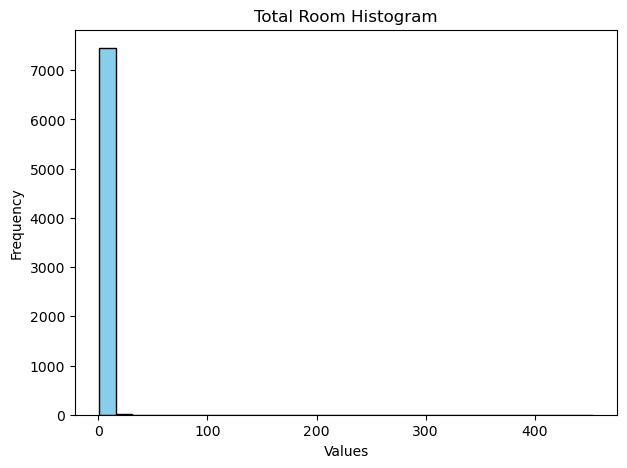

In [27]:
plt.figure(figsize=(7, 5))
plt.hist(df33["Total_Room"], bins=30, color='skyblue', edgecolor='black')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Total Room Histogram')

plt.show()

In [28]:
# Silmek istediğiniz değerleri bir liste içinde tanımlayın
outlier_Values_Total_Room = [130, 453]

# .isin() metodu ile bu değerlere sahip olan satırları bulup,
# ~ operatörü ile bu seçimi tersine çevirerek geri kalanları seçiyoruz.
df33_cleaned = df33[~df33['Total_Room'].isin(outlier_Values_Total_Room)]


# --- Sildikten Sonraki Durum ---
print("--- Belirtilen Değerler Silindikten Sonraki Hali ---")
print(f"\nTemizlenmiş Satır Sayısı: {len(df33_cleaned)}")
print(f"Silinen Satır Sayısı: {len(df33) - len(df33_cleaned)}")

--- Belirtilen Değerler Silindikten Sonraki Hali ---

Temizlenmiş Satır Sayısı: 7461
Silinen Satır Sayısı: 2


In [29]:
df33_cleaned.Total_Room.unique()

array([ 3,  4,  5,  2,  6,  7,  1,  8, 10,  9, 13, 11, 21, 18, 16, 17, 25,
       14, 12, 15, 24, 84, 20], dtype=int64)

In [30]:
print(df33_cleaned['Total_Room'].value_counts())

Total_Room
3     2969
4     2294
2      684
5      661
6      420
7      215
8       89
9       37
1       35
10      15
12      10
11       7
13       5
14       4
15       4
16       3
17       2
25       2
21       1
18       1
24       1
84       1
20       1
Name: count, dtype: int64


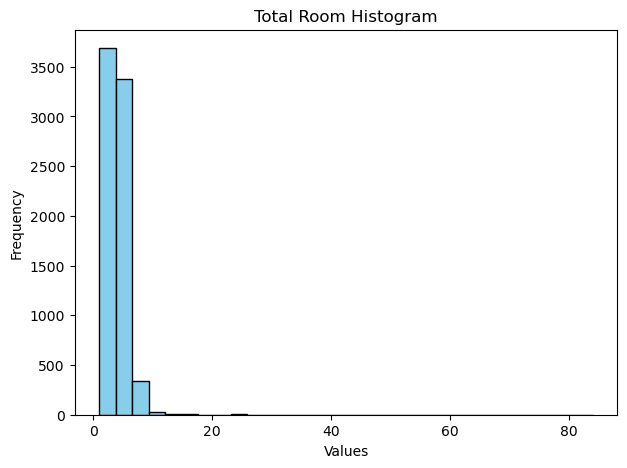

In [31]:
plt.figure(figsize=(7, 5))
plt.hist(df33_cleaned["Total_Room"], bins=30, color='skyblue', edgecolor='black')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Total Room Histogram')

plt.show()

In [32]:
df34 = df33_cleaned.copy()

## 3.4 "Bathroom_Count" Column (DF34)

### 3.4.1 Filling the blanks

In [33]:
# Check null values
df34.Bathroom_Count.isnull().sum()

106

In [34]:
df34.Bathroom_Count.unique()

array([ 1.,  2.,  3., nan,  4.,  7.,  6.,  5.,  8., 24., 10., 17., 21.,
        9., 20.])

In [35]:
# --- Before cleaning ---
print("\n Blanks before cleaning:")
df34_with_blank = df34
print(df34_with_blank['Bathroom_Count'].isnull().sum())
print("-" * 40)

# --- Doldurma İşlemi ---

# Kural 1: 'Total_Room' 1, 2, 3 veya 4 ise ve 'Bathroom_Count' boş ise, değeri 1 yap.
# (df['Total_Room'] <= 4) koşulu [1, 2, 3, 4] değerlerini kapsar.
df34.loc[(df34['Bathroom_Count'].isnull()) & (df34['Total_Room'] <= 4), 'Bathroom_Count'] = 1

# Kural 2: 'Total_Room' 5 veya 5'ten büyük ise ve 'Bathroom_Count' boş ise, değeri 2 yap.
df34.loc[(df34['Bathroom_Count'].isnull()) & (df34['Total_Room'] >= 5), 'Bathroom_Count'] = 2


# --- After cleaning ---
print("\n After before cleaning:")
print(df34['Bathroom_Count'].isnull().sum())


 Blanks before cleaning:
106
----------------------------------------

 After before cleaning:
0


### 3.4.2 Outlier Cleaning

In [36]:
df34.Bathroom_Count.value_counts()

Bathroom_Count
1.0     4233
2.0     2464
3.0      474
4.0      179
5.0       61
6.0       27
7.0       11
10.0       5
8.0        2
24.0       1
17.0       1
21.0       1
9.0        1
20.0       1
Name: count, dtype: int64

In [37]:
# Deleting "24" value
#df34_cleaned = df34[df34['Bathroom_Count'] != 24]
df34_cleaned = df34[~df34['Bathroom_Count'].isin([20, 21, 24])]
df34_cleaned.Bathroom_Count.value_counts()

Bathroom_Count
1.0     4233
2.0     2464
3.0      474
4.0      179
5.0       61
6.0       27
7.0       11
10.0       5
8.0        2
17.0       1
9.0        1
Name: count, dtype: int64

In [38]:
df35 = df34_cleaned.copy()

## 3.5 "Net_M2" Column (DF35)

### 3.5.1 Changing format

In [39]:
df35.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7458 entries, 0 to 9203
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 7458 non-null   int64  
 1   Location              7458 non-null   object 
 2   Total_Room            7458 non-null   int64  
 3   Bathroom_Count        7458 non-null   float64
 4   Net_M2                7458 non-null   object 
 5   Number_of_Floors      7458 non-null   object 
 6   Floor                 7138 non-null   object 
 7   Building_Age          7458 non-null   object 
 8   Heating_Type          7458 non-null   object 
 9   Deed_Status           7456 non-null   object 
 10  Furnished_Status      7058 non-null   object 
 11  Building_Type         3894 non-null   object 
 12  Is_New_Building       4056 non-null   object 
 13  Occupancy_Status      7239 non-null   object 
 14  Swap                  6931 non-null   object 
 15  In_a_Complex          1653

In [40]:
df35.Net_M2.isnull().sum()

0

In [41]:
df35.Net_M2.unique()

array(['80 m2  / 70 m2', '90 m2  / 80 m2', '125 m2  / 95 m2', ...,
       '299 m2  / 289 m2', '76 m2  / 55 m2', '120 m2  / 82 m2'],
      dtype=object)

In [42]:
df35.Net_M2.value_counts()

Net_M2
90 m2  / 80 m2      172
100 m2  / 90 m2     163
110 m2  / 100 m2    152
85 m2  / 80 m2      129
85 m2  / 75 m2      124
                   ... 
246 m2  / 138 m2      1
100 m2  / 76 m2       1
350 m2  / 245 m2      1
147 m2  / 127 m2      1
120 m2  / 82 m2       1
Name: count, Length: 1794, dtype: int64

In [43]:
# Changing format

df35 = df35.copy()

# 1. Adım: .str.extract() ile slash'tan sonraki ilk sayı grubunu çekip al.
# r'/\s*(\d+)' ifadesi "bir / karakteri, ardından sıfır veya daha fazla boşluk
# ve ardından yakalanacak bir veya daha fazla rakam" anlamına gelir.
df35['Net_M2'] = df35['Net_M2'].str.extract(r'/\s*(\d+)', expand=False)

# 2. Adım: Çekilen değerleri sayısal formata dönüştür.
# errors='coerce', sayıya dönüştürülemeyen (eşleşme bulunamayan) değerleri
# geçersiz sayı (NaN) olarak işaretler, bu da hataları önler.
df35['Net_M2'] = pd.to_numeric(df35['Net_M2'], errors='coerce')

print("--- After transformation ---")
print("\nNew Value Type:", df35['Net_M2'].dtype)

--- After transformation ---

New Value Type: int64


In [44]:
df35.Net_M2.value_counts()

Net_M2
80     479
90     467
100    426
75     366
85     349
      ... 
251      1
176      1
159      1
163      1
288      1
Name: count, Length: 297, dtype: int64

### 3.5.2 Cleaning outliers

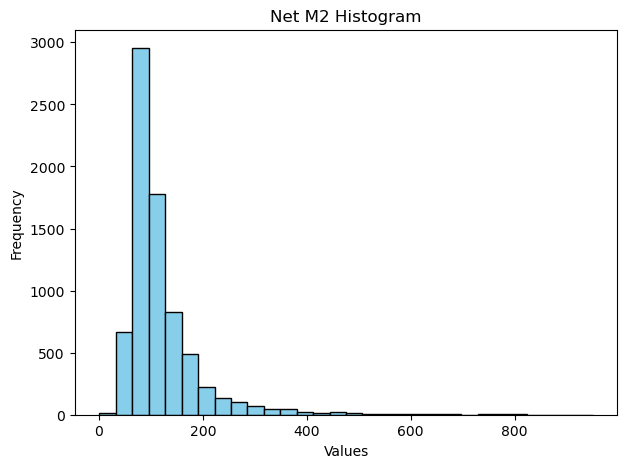

In [45]:
plt.figure(figsize=(7, 5))
plt.hist(df35["Net_M2"], bins=30, color='skyblue', edgecolor='black')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Net M2 Histogram')

plt.show()

In [46]:
# Veriyi karıştıralım ki sıralı olmasın
df35 = df35.sample(frac=1).reset_index(drop=True)


# --- En Büyük 10 Değeri Listeleme ---

print("--- Biggest Values ---")
# df.nlargest(n, columns) metodu, belirtilen sütun(lar)a göre en büyük n satırı döndürür.
en_buyuk_10 = df35.nlargest(20, 'Net_M2')
print(en_buyuk_10.Net_M2)
print("-" * 45)


# --- En Küçük 10 Değeri Listeleme ---

print("\n--- Smallest Values ---")
# df.nsmallest(n, columns) metodu, belirtilen sütun(lar)a göre en küçük n satırı döndürür.
en_kucuk_10 = df35.nsmallest(20, 'Net_M2')
print(en_kucuk_10.Net_M2)

--- Biggest Values ---
6807    950
3927    900
55      840
4520    801
3102    800
5855    783
7145    779
3312    763
1164    755
63      750
5410    750
5437    750
7263    700
4789    695
737     690
5591    685
4627    680
4005    660
3873    650
5887    640
Name: Net_M2, dtype: int64
---------------------------------------------

--- Smallest Values ---
102      1
4314     1
4342     8
5361     8
6946     8
3028    20
4355    24
3       26
4770    26
6410    26
817     28
4469    29
2841    30
4207    30
4883    30
5133    30
2876    33
4084    33
694     34
2569    34
Name: Net_M2, dtype: int64


In [47]:
print(f"\n Row number before cleaning: {len(df35)}")
print("-" * 40)

df35_cleaned = df35[df35['Net_M2'].between(20, 300)]

print(f"\n Row number after cleaning: {len(df35_cleaned)}")
print(f" Deleted row number: {len(df35) - len(df35_cleaned)}")


 Row number before cleaning: 7458
----------------------------------------

 Row number after cleaning: 7239
 Deleted row number: 219


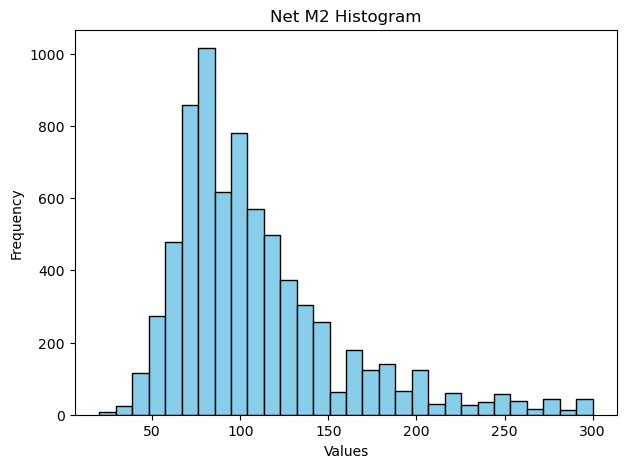

In [48]:
plt.figure(figsize=(7, 5))
plt.hist(df35_cleaned["Net_M2"], bins=30, color='skyblue', edgecolor='black')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Net M2 Histogram')

plt.show()

In [49]:
df35_cleaned.Net_M2.value_counts()

Net_M2
80     479
90     467
100    426
75     366
85     349
      ... 
224      1
287      1
28       1
269      1
248      1
Name: count, Length: 223, dtype: int64

In [50]:
# Veriyi karıştıralım ki sıralı olmasın
df35_cleaned = df35_cleaned.sample(frac=1).reset_index(drop=True)


# --- En Büyük 10 Değeri Listeleme ---

print("--- Biggest Values ---")
# df.nlargest(n, columns) metodu, belirtilen sütun(lar)a göre en büyük n satırı döndürür.
en_buyuk_10 = df35_cleaned.nlargest(20, 'Net_M2')
print(en_buyuk_10.Net_M2)
print("-" * 45)


# --- En Küçük 10 Değeri Listeleme ---

print("\n--- Smallest Values ---")
# df.nsmallest(n, columns) metodu, belirtilen sütun(lar)a göre en küçük n satırı döndürür.
en_kucuk_10 = df35_cleaned.nsmallest(20, 'Net_M2')
print(en_kucuk_10.Net_M2)

--- Biggest Values ---
722     300
736     300
942     300
1663    300
1786    300
1789    300
1831    300
1867    300
2024    300
2123    300
2161    300
2196    300
2356    300
2525    300
2714    300
3532    300
3745    300
4238    300
4335    300
4340    300
Name: Net_M2, dtype: int64
---------------------------------------------

--- Smallest Values ---
750     20
5734    24
971     26
3392    26
6901    26
1184    28
2080    29
1085    30
2464    30
5498    30
7199    30
1914    33
7042    33
640     34
6727    34
478     35
698     35
1088    35
1899    35
3524    35
Name: Net_M2, dtype: int64


In [51]:
df36 = df35_cleaned.copy()

## 3.6 "Number_of_Floors" Column (DF36)

### 3.6.1 Changing format

In [52]:
df36.Number_of_Floors.isnull().sum()

0

In [53]:
df36.Number_of_Floors.value_counts()

Number_of_Floors
4 Katlı      1766
5 Katlı      1748
3 Katlı       734
6 Katlı       598
7 Katlı       321
8 Katlı       278
10 Katlı      244
9 Katlı       226
2 Katlı       178
14 Katlı      168
12 Katlı      165
11 Katlı      130
13 Katlı      124
30 Katlı      110
15 Katlı       91
24 Katlı       35
17 Katlı       34
1 Katlı        33
18 Katlı       31
16 Katlı       29
20 Katlı       25
21 Katlı       22
22 Katlı       20
25 Katlı       19
19 Katlı       15
23 Katlı       15
33 Katlı       11
29 Katlı       11
32 Katlı       10
27 Katlı        8
28 Katlı        5
26 Katlı        5
31 Katlı        5
34 Katlı        5
43 Katlı        4
40 Katlı        3
46 Katlı        2
36 Katlı        2
41 Katlı        2
50 Katlı        1
42 Katlı        1
35 Katlı        1
101 Katlı       1
45 Katlı        1
44 Katlı        1
48 Katlı        1
Name: count, dtype: int64

In [54]:
print("\nOriginal Data Type:", df36['Number_of_Floors'].dtype)
print("-" * 45)

# 1. Adım: .str.extract() ile metindeki ilk sayı grubunu çekip al.
# r'(\d+)' deseni, "bir veya daha fazla rakamdan oluşan grubu yakala" demektir.
df36['Number_of_Floors'] = df36['Number_of_Floors'].str.extract(r'(\d+)', expand=False)

# 2. Adım: Çıkarılan metin halindeki sayıları gerçek sayısal formata dönüştür.
# errors='coerce', sayıya dönüştürülemeyen ("Tek Katlı" gibi) değerleri
# hata vermeden boş değere (NaN) çevirir.
df36['Number_of_Floors'] = pd.to_numeric(df36['Number_of_Floors'], errors='coerce')

print("\nNew Data Type:", df36['Number_of_Floors'].dtype)


Original Data Type: object
---------------------------------------------

New Data Type: int64


### 3.6.2 Cleaning Outliers

In [55]:
df36.Number_of_Floors.value_counts()

Number_of_Floors
4      1766
5      1748
3       734
6       598
7       321
8       278
10      244
9       226
2       178
14      168
12      165
11      130
13      124
30      110
15       91
24       35
17       34
1        33
18       31
16       29
20       25
21       22
22       20
25       19
19       15
23       15
33       11
29       11
32       10
27        8
28        5
26        5
31        5
34        5
43        4
40        3
46        2
36        2
41        2
50        1
42        1
35        1
101       1
45        1
44        1
48        1
Name: count, dtype: int64

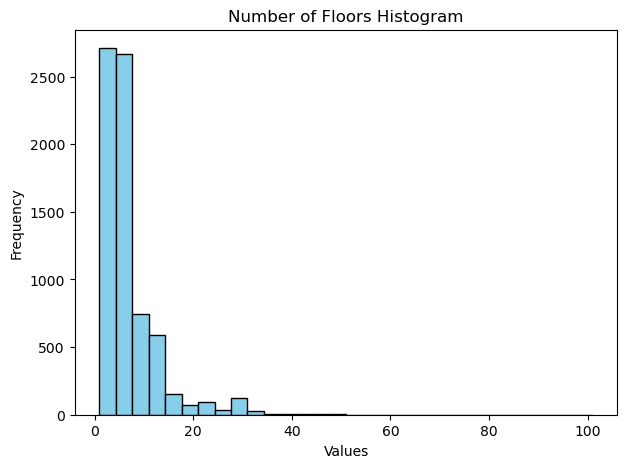

In [56]:
plt.figure(figsize=(7, 5))
plt.hist(df36["Number_of_Floors"], bins=30, color='skyblue', edgecolor='black')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Number of Floors Histogram')

plt.show()

In [57]:
print(f"\n Row number before cleaning: {len(df36)}")
print("-" * 40)

df36_cleaned = df36[df36['Number_of_Floors'].between(0, 25)]

print(f"\n Row number after cleaning: {len(df36_cleaned)}")
print(f" Deleted row number: {len(df36) - len(df36_cleaned)}")


 Row number before cleaning: 7239
----------------------------------------

 Row number after cleaning: 7049
 Deleted row number: 190


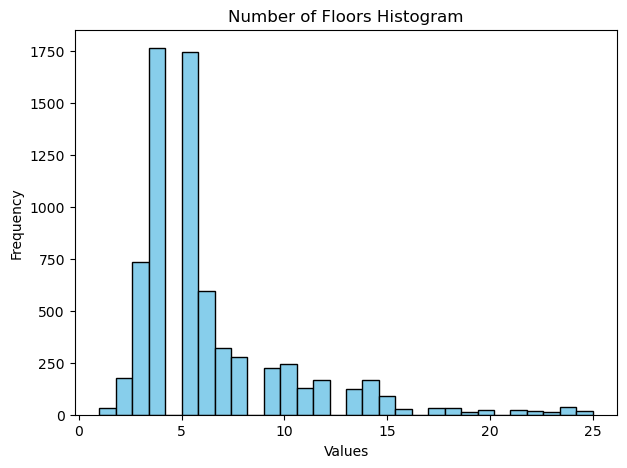

In [58]:
plt.figure(figsize=(7, 5))
plt.hist(df36_cleaned["Number_of_Floors"], bins=30, color='skyblue', edgecolor='black')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Number of Floors Histogram')

plt.show()

In [59]:
df36_cleaned.Number_of_Floors.value_counts()

Number_of_Floors
4     1766
5     1748
3      734
6      598
7      321
8      278
10     244
9      226
2      178
14     168
12     165
11     130
13     124
15      91
24      35
17      34
1       33
18      31
16      29
20      25
21      22
22      20
25      19
19      15
23      15
Name: count, dtype: int64

In [60]:
df36_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7049 entries, 0 to 7238
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 7049 non-null   int64  
 1   Location              7049 non-null   object 
 2   Total_Room            7049 non-null   int64  
 3   Bathroom_Count        7049 non-null   float64
 4   Net_M2                7049 non-null   int64  
 5   Number_of_Floors      7049 non-null   int64  
 6   Floor                 6835 non-null   object 
 7   Building_Age          7049 non-null   object 
 8   Heating_Type          7049 non-null   object 
 9   Deed_Status           7047 non-null   object 
 10  Furnished_Status      6676 non-null   object 
 11  Building_Type         3723 non-null   object 
 12  Is_New_Building       3884 non-null   object 
 13  Occupancy_Status      6852 non-null   object 
 14  Swap                  6554 non-null   object 
 15  In_a_Complex          1408

In [61]:
df37 = df36_cleaned.copy()

## 3.7 "Floor" Column (DF37)

### 3.7.1 Changing format

In [62]:
df37.Floor.value_counts()

Floor
1. Kat             919
3. Kat             910
2. Kat             828
4. Kat             754
Bahçe Katı         550
Yüksek Giriş       486
5. Kat             411
Ara Kat            280
Giriş Katı         235
6. Kat             217
7. Kat             189
En Üst Kat         164
8. Kat             153
9. Kat             103
10. Kat            100
Kot 1               80
11. Kat             61
Çatı Katı           57
Zemin               41
13. Kat             40
Yarı Bodrum         37
12. Kat             36
Kot 2               32
14. Kat             27
15. Kat             26
16. Kat             17
21 ve üzeri         15
Teras Katı          14
Kot 3               10
Bodrum              10
Villa Katı           9
17. Kat              8
18. Kat              7
Bodrum ve Zemin      6
Tripleks             2
20. Kat              1
Name: count, dtype: int64

In [63]:

# 1. ADIM: Sayı içeren ("1. Kat", "21 ve üzeri") değerleri ayıkla.
# Bu en genel kural olduğu için en başta yapmak, sonraki adımları basitleştirir.
# r'(\d+)' deseni, metindeki ilk sayı grubunu bulur.
extracted_numbers = df37['Floor'].str.extract(r'(\d+)', expand=False)
# Sadece sayı bulunan satırları bu yeni değerlerle güncelleyelim.
# np.where(koşul, doğruysa_bunu_yap, yanlışsa_bunu_yap)
df37['Floor'] = np.where(extracted_numbers.notna(), extracted_numbers, df37['Floor'])


# 2. ADIM: Statik ve basit eşleşmeleri bir sözlük (dictionary) kullanarak yapalım.
# Bu, birden fazla .loc kullanmaktan çok daha temiz ve verimlidir.
mapping_dict = {
    # Değeri 1 olacaklar
    'Bahçe Katı': 1,
    'Yüksek Giriş': 1,
    'Ara Kat': 1,
    'Giriş Katı': 1,
    'Zemin': 1,
    'Yarı Bodrum': 1,
    'Villa Katı': 1,
    # Değeri -1 olacaklar
    'Bodrum': -1,
    'Bodrum ve Zemin': -1,
    'Kot 1': -1,
    # Diğer kotlar
    'Kot 2': -2,
    'Kot 3': -3
}
df37['Floor'] = df37['Floor'].replace(mapping_dict)


# 3. ADIM: Özel koşul gerektiren ("En Üst Kat" vb.) değerleri .loc ile güncelleyelim.
# Bu değerler, 'Number_of_Floors' sütununa bağlı olduğu için ayrı yapılır.
top_floor_values = ['Çatı Katı', 'En Üst Kat', 'Teras Katı', 'Tripleks']
condition = df37['Floor'].isin(top_floor_values)
# Koşulu sağlayan satırlarda 'Floor' sütununu, 'Number_of_Floors' sütunundaki değerle güncelle.
df37.loc[condition, 'Floor'] = df37['Number_of_Floors']


# 4. ADIM: Son olarak, tüm sütunu sayısal bir formata dönüştürelim.
# Artık sütundaki tüm değerler ya sayı ya da sayıya çevrilebilen metinler olmalı.
# errors='coerce', kalan metinleri (örn: "Bilinmiyor") hata vermeden NaN'e çevirir.
df37['Floor'] = pd.to_numeric(df37['Floor'], errors='coerce')


# --- Dönüşümden Sonraki Durum ---

print("\nTemizlenmiş Sütunun Veri Tipi:", df37['Floor'].dtype)
df37.Floor.value_counts()


Temizlenmiş Sütunun Veri Tipi: float64


Floor
 1.0     2637
 3.0      954
 2.0      869
 4.0      825
 5.0      487
 6.0      240
 7.0      198
 8.0      157
 9.0      106
 10.0     102
 11.0      64
 13.0      41
 12.0      37
 14.0      27
 15.0      26
 16.0      17
-1.0       16
 21.0      15
 17.0       8
 18.0       7
 19.0       1
 20.0       1
Name: count, dtype: int64

### 3.7.2 Filling empty datas

In [64]:
df37.Floor.isnull().sum()

214

In [65]:
df37['Floor'].fillna(1, inplace=True)

C:\Users\emir\AppData\Local\Temp\ipykernel_17692\4157628233.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df37['Floor'].fillna(1, inplace=True)


In [66]:
df37.Floor.isnull().sum()

0

In [67]:
df37.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7049 entries, 0 to 7238
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 7049 non-null   int64  
 1   Location              7049 non-null   object 
 2   Total_Room            7049 non-null   int64  
 3   Bathroom_Count        7049 non-null   float64
 4   Net_M2                7049 non-null   int64  
 5   Number_of_Floors      7049 non-null   int64  
 6   Floor                 7049 non-null   float64
 7   Building_Age          7049 non-null   object 
 8   Heating_Type          7049 non-null   object 
 9   Deed_Status           7047 non-null   object 
 10  Furnished_Status      6676 non-null   object 
 11  Building_Type         3723 non-null   object 
 12  Is_New_Building       3884 non-null   object 
 13  Occupancy_Status      6852 non-null   object 
 14  Swap                  6554 non-null   object 
 15  In_a_Complex          1408

In [68]:
df37.Floor.unique()

array([ 1.,  2.,  6.,  5.,  3.,  8., 21.,  4.,  7.,  9., 10., 15., 11.,
       12., 14., 16., 13., -1., 17., 18., 19., 20.])

In [69]:
df38 = df37

## 3.8 "Building_Age" Column

### 3.8.1 Changing Format

In [70]:
df38.Building_Age.unique()

array(['Sıfır Bina', '26 Yaşında', '9 Yaşında', '31 Yaşında',
       '15 Yaşında', '21 Yaşında', '17 Yaşında', '11 Yaşında',
       '18 Yaşında', '2 Yaşında', '1 Yaşında', '8 Yaşında', '5 Yaşında',
       '13 Yaşında', '10 Yaşında', '29 Yaşında', '6 Yaşında',
       '30 Yaşında', '28 Yaşında', '35 Yaşında', '25 Yaşında',
       '48 Yaşında', '16 Yaşında', '7 Yaşında', '41 Yaşında',
       '36 Yaşında', '27 Yaşında', '33 Yaşında', '90 Yaşında',
       '40 Yaşında', '4 Yaşında', '3 Yaşında', '14 Yaşında', '45 Yaşında',
       '38 Yaşında', '37 Yaşında', '23 Yaşında', '12 Yaşında',
       '20 Yaşında', '34 Yaşında', '100 Yaşında', '22 Yaşında',
       '55 Yaşında', '39 Yaşında', '19 Yaşında', '54 Yaşında',
       '24 Yaşında', '43 Yaşında', '50 Yaşında', '60 Yaşında',
       '44 Yaşında', '32 Yaşında', '65 Yaşında', '42 Yaşında',
       '53 Yaşında', '80 Yaşında', '104 Yaşında', '63 Yaşında',
       '47 Yaşında', '120 Yaşında', '49 Yaşında', '51 Yaşında',
       '99 Yaşında', '125 Yaşında

In [71]:
df38.Building_Age.value_counts()

Building_Age
Sıfır Bina     1560
1 Yaşında       850
11 Yaşında      395
5 Yaşında       353
31 Yaşında      281
               ... 
99 Yaşında        1
120 Yaşında       1
63 Yaşında        1
104 Yaşında       1
94 Yaşında        1
Name: count, Length: 74, dtype: int64

In [72]:
# 1. Adım: Özel durum olan 'Sıfır Bina' metnini sayısal karşılığı olan '0' ile değiştir.
df38['Building_Age'] = df38['Building_Age'].replace('Sıfır Bina', '0')

# 2. Adım: .str.extract() ile her metindeki sayı grubunu çekip al.
# r'(\d+)' deseni, "bir veya daha fazla rakamdan oluşan grubu yakala" demektir.
# Bu desen hem "40 Yaşında" içindeki "40"ı, hem de bir önceki adımda değiştirdiğimiz "0"ı yakalar.
df38['Building_Age'] = df38['Building_Age'].str.extract(r'(\d+)', expand=False)

# 3. Adım: Çıkarılan metin halindeki sayıları gerçek sayısal formata dönüştür.
# errors='coerce', herhangi bir nedenle sayıya dönüştürülemeyen bir değer olursa
# (örn: tamamen boş veya beklenmedik bir metin) hata vermeden onu boş değere (NaN) çevirir.
df38['Building_Age'] = pd.to_numeric(df38['Building_Age'], errors='coerce')

In [73]:
df38.Building_Age.unique()

array([  0,  26,   9,  31,  15,  21,  17,  11,  18,   2,   1,   8,   5,
        13,  10,  29,   6,  30,  28,  35,  25,  48,  16,   7,  41,  36,
        27,  33,  90,  40,   4,   3,  14,  45,  38,  37,  23,  12,  20,
        34, 100,  22,  55,  39,  19,  54,  24,  43,  50,  60,  44,  32,
        65,  42,  53,  80, 104,  63,  47, 120,  49,  51,  99, 125,  58,
        52,  68,  56, 143,  75,  85, 124,  61,  94], dtype=int64)

In [74]:
df38.Building_Age.value_counts()

Building_Age
0      1560
1       850
11      395
5       353
31      281
       ... 
99        1
120       1
63        1
104       1
94        1
Name: count, Length: 74, dtype: int64

### 3.8.2 Cleaning Outliers (Grouping)

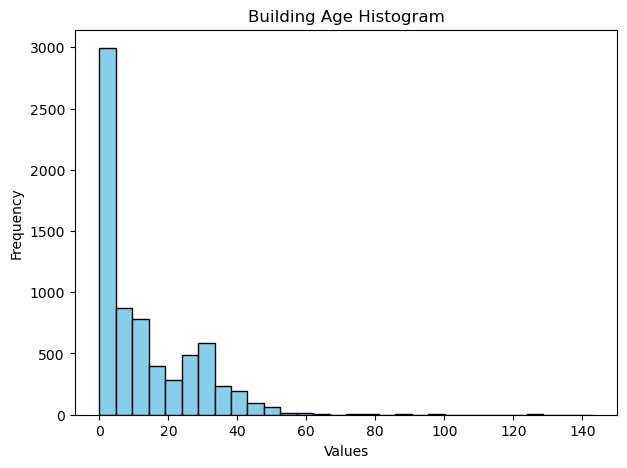

In [75]:
plt.figure(figsize=(7, 5))
plt.hist(df38["Building_Age"], bins=30, color='skyblue', edgecolor='black')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Building Age Histogram')

plt.show()

In [76]:
# 50 yaşından büyük değerler 50'ye sabitlenir
#df38['Building_Age'] = df38['Building_Age'].apply(lambda age: 50 if age > 50 else age)

In [77]:
# --- ADIM 1: Değerleri Sınırlandırma (Capping) ---
# 80'den büyük olan tüm değerleri 80'e eşitliyoruz.
# .loc kullanarak bu işlemi yapmak en verimli yoldur.
top_limit = 70
df38.loc[df38['Building_Age'] > top_limit, 'Building_Age'] = top_limit

print(f"--- {top_limit}'den Büyük Değerler Sınırlandırıldıktan Sonra ---")
print(df38['Building_Age'].value_counts().sort_index())
print("-" * 50)


# --- ADIM 2: Değerleri Gruplandırma (Binning) ---
# pd.cut fonksiyonunu kullanarak yaşları belirli aralıklara ayıracağız.

# 1. Aralıkların sınırlarını tanımla. -1'den başlamak, 0'ın da ilk gruba dahil olmasını sağlar.
bins = [-1, 0, 5, 10, 20, 30, 40, 50, 70]

# 2. Her aralığa verilecek etiketleri (isimleri) tanımla.
labels = ['0', "1-5", "6-10", '11-20', '21-30', '31-40', '41-50', '51-70']

# 3. pd.cut fonksiyonunu uygula ve sonucu yeni bir sütuna ata.
df38['Building_Age_Group'] = pd.cut(df38['Building_Age'], bins=bins, labels=labels, right=True)


# --- Son Durum ---
print("--- Gruplandırma İşlemi Tamamlandıktan Sonraki Hali ---")
# Hem orijinal sütunu hem de yeni grup sütununu birlikte görelim.
print(df38[['Building_Age', 'Building_Age_Group']])

print("\n--- Yeni 'Building_Age_Group' Sütununun Dağılımı ---")
print(df38['Building_Age_Group'].value_counts().sort_index())

--- 70'den Büyük Değerler Sınırlandırıldıktan Sonra ---
Building_Age
0     1560
1      850
2      160
3      169
4      255
      ... 
61       1
63       1
65       3
68       1
70      21
Name: count, Length: 63, dtype: int64
--------------------------------------------------
--- Gruplandırma İşlemi Tamamlandıktan Sonraki Hali ---
      Building_Age Building_Age_Group
0                0                  0
1               26              21-30
2                9               6-10
3               31              31-40
4               15              11-20
...            ...                ...
7234            30              21-30
7235             7               6-10
7236             1                1-5
7237             1                1-5
7238            21              21-30

[7049 rows x 2 columns]

--- Yeni 'Building_Age_Group' Sütununun Dağılımı ---
Building_Age_Group
0        1560
1-5      1787
6-10      710
11-20    1071
21-30     957
31-40     743
41-50     167
51-70      54

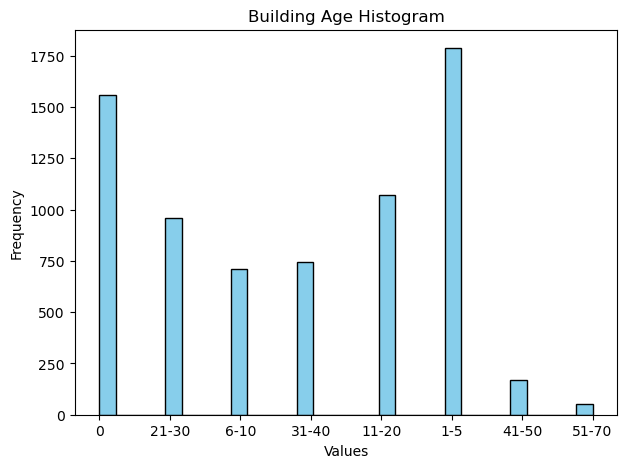

In [78]:
plt.figure(figsize=(7, 5))
plt.hist(df38["Building_Age_Group"], bins=30, color='skyblue', edgecolor='black')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Building Age Histogram')

plt.show()

In [79]:
df38.Building_Age_Group.unique()

['0', '21-30', '6-10', '31-40', '11-20', '1-5', '41-50', '51-70']
Categories (8, object): ['0' < '1-5' < '6-10' < '11-20' < '21-30' < '31-40' < '41-50' < '51-70']

### 3.8.3 One Hot Encoding

In [80]:
# 'Building_Age_Group' sütununu One-Hot Encoding ile yeni sütunlara dönüştür
df38_encoded = pd.get_dummies(df38, columns=['Building_Age_Group'], prefix='Age',dtype=int)

# Orijinal 'Building_Age' sütununu artık kullanmayacağımız için düşürebiliriz
df38_encoded.drop('Building_Age', axis=1, inplace=True)

# Sonucu gör
print(df38_encoded.head())

      Price                                    Location  Total_Room  \
0   5500000  İstanbul - Beylikdüzü - Adnan Kahveci Mah.           3   
1   3750000      İstanbul - Küçükçekmece - Gültepe Mah.           3   
2  23750000         İstanbul - Kadıköy - Feneryolu Mah.           4   
3  11500000           İstanbul - Kadıköy - Erenköy Mah.           3   
4   3250000     İstanbul - Sultangazi - Yunus Emre Mah.           3   

   Bathroom_Count  Net_M2  Number_of_Floors  Floor   Heating_Type  \
0             1.0     100                 6    1.0          Kombi   
1             1.0      85                 2    2.0          Kombi   
2             2.0     139                 6    6.0  Yerden Isıtma   
3             1.0      90                 3    2.0          Kombi   
4             1.0      90                 5    1.0          Kombi   

     Deed_Status Furnished_Status  ... KonutTipi_Mustakil KonutTipi_Yali  \
0  Kat Mülkiyeti     Eşyalı Değil  ...                  0              0   
1   Hi

In [81]:
df38_encoded.Age_0

0       1
1       0
2       0
3       0
4       0
       ..
7234    0
7235    0
7236    0
7237    0
7238    0
Name: Age_0, Length: 7049, dtype: int32

In [82]:
df38_encoded.columns

Index(['Price', 'Location', 'Total_Room', 'Bathroom_Count', 'Net_M2',
       'Number_of_Floors', 'Floor', 'Heating_Type', 'Deed_Status',
       'Furnished_Status', 'Building_Type', 'Is_New_Building',
       'Occupancy_Status', 'Swap', 'In_a_Complex', 'Loan_Eligibility', 'Vs30',
       'KonutTipi_Bina', 'KonutTipi_Daire', 'KonutTipi_Kooperatif',
       'KonutTipi_Mustakil', 'KonutTipi_Yali', 'Age_0', 'Age_1-5', 'Age_6-10',
       'Age_11-20', 'Age_21-30', 'Age_31-40', 'Age_41-50', 'Age_51-70'],
      dtype='object')

In [83]:
df39 = df38_encoded

## 3.9 "Heating_Type" Column (DF39)

### 3.9.1 Formatting values

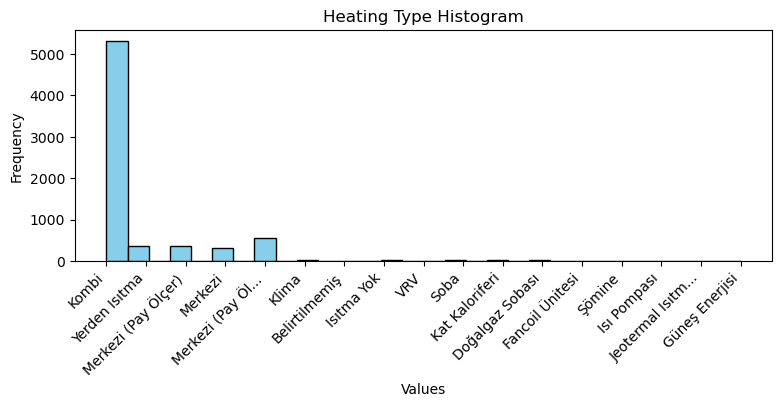

In [84]:
plt.figure(figsize=(9, 3))
plt.hist(df39["Heating_Type"], bins=30, color='skyblue', edgecolor='black')

plt.xticks(rotation=45, ha='right')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Heating Type Histogram')

plt.show()

In [85]:
df39.Heating_Type.unique()

array(['Kombi', 'Yerden Isıtma', 'Merkezi (Pay Ölçer)', 'Merkezi',
       'Merkezi (Pay Öl...', 'Klima', 'Belirtilmemiş', 'Isıtma Yok',
       'VRV', 'Soba', 'Kat Kaloriferi', 'Doğalgaz Sobası',
       'Fancoil Ünitesi', 'Şömine', 'Isı Pompası', 'Jeotermal Isıtm...',
       'Güneş Enerjisi'], dtype=object)

In [86]:
df39.Heating_Type.isnull().sum()

0

In [87]:
heating_map = {
    # Grup 1: Kombi / Bireysel Doğalgaz
    'Kombi': 'Kombi-Bireysel Doğalgaz',
    'Kat Kaloriferi': 'Kombi-Bireysel Doğalgaz',

    # Grup 2: Merkezi Sistem
    'Merkezi': 'Merkezi Sistem',
    'Merkezi (Pay Öl...)': 'Merkezi Sistem',
    'Merkezi (Pay Ölçer)': 'Merkezi Sistem',

    # Grup 3: Yerden Isıtma / Modern
    'Yerden Isıtma': 'Yerden Isıtma-Modern',
    'Isı Pompası': 'Yerden Isıtma-Modern',
    'Fancoil Ünitesi': 'Yerden Isıtma-Modern',
    'VRV': 'Yerden Isıtma-Modern',

    # Grup 4: Soba / Geleneksel
    'Doğalgaz Sobası': 'Soba-Geleneksel',
    'Soba': 'Soba-Geleneksel',
    'Şömine': 'Soba-Geleneksel',

    # Grup 5: Diğer / Belirsiz
    'Klima': 'Diger-Belirsiz',
    'Isıtma Yok': 'Diger-Belirsiz',
    'Belirtilmemiş': 'Diger-Belirsiz',
    'Jeotermal Isıtm...': 'Diger-Belirsiz'
}

df39['Heating_Type_Grouped'] = df39['Heating_Type'].map(heating_map)

df39['Heating_Type_Grouped'].fillna('Diger-Belirsiz', inplace=True)

C:\Users\emir\AppData\Local\Temp\ipykernel_17692\254496533.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df39['Heating_Type_Grouped'].fillna('Diger-Belirsiz', inplace=True)


In [88]:
df39.Heating_Type_Grouped.unique()

array(['Kombi-Bireysel Doğalgaz', 'Yerden Isıtma-Modern',
       'Merkezi Sistem', 'Diger-Belirsiz', 'Soba-Geleneksel'],
      dtype=object)

In [89]:
df39.Heating_Type_Grouped.isnull().sum()

0

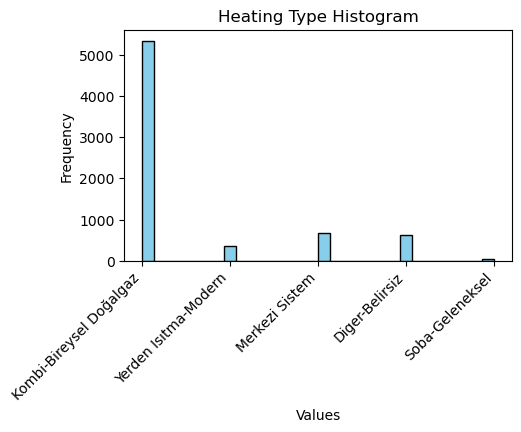

In [90]:
plt.figure(figsize=(5, 3))
plt.hist(df39["Heating_Type_Grouped"], bins=30, color='skyblue', edgecolor='black')

plt.xticks(rotation=45, ha='right')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Heating Type Histogram')

plt.show()

### 3.9.2 One-Hot Encoding

In [91]:
print("\nOriginal Columns:")
print(df39.columns)
print("-" * 50)

df39_encoded = pd.get_dummies(df39, columns=['Heating_Type_Grouped'], prefix='Heating',dtype=int)

# axis=1: Silme işleminin sütunlar üzerinde yapılacağını belirtir.
df39_encoded.drop('Heating_Type', axis=1, inplace=True)

print("\nNew Columns:")
print(df39_encoded.columns)


Original Columns:
Index(['Price', 'Location', 'Total_Room', 'Bathroom_Count', 'Net_M2',
       'Number_of_Floors', 'Floor', 'Heating_Type', 'Deed_Status',
       'Furnished_Status', 'Building_Type', 'Is_New_Building',
       'Occupancy_Status', 'Swap', 'In_a_Complex', 'Loan_Eligibility', 'Vs30',
       'KonutTipi_Bina', 'KonutTipi_Daire', 'KonutTipi_Kooperatif',
       'KonutTipi_Mustakil', 'KonutTipi_Yali', 'Age_0', 'Age_1-5', 'Age_6-10',
       'Age_11-20', 'Age_21-30', 'Age_31-40', 'Age_41-50', 'Age_51-70',
       'Heating_Type_Grouped'],
      dtype='object')
--------------------------------------------------

New Columns:
Index(['Price', 'Location', 'Total_Room', 'Bathroom_Count', 'Net_M2',
       'Number_of_Floors', 'Floor', 'Deed_Status', 'Furnished_Status',
       'Building_Type', 'Is_New_Building', 'Occupancy_Status', 'Swap',
       'In_a_Complex', 'Loan_Eligibility', 'Vs30', 'KonutTipi_Bina',
       'KonutTipi_Daire', 'KonutTipi_Kooperatif', 'KonutTipi_Mustakil',
       'Kon

In [92]:
df310 = df39_encoded

## 3.10 "Deed_Status" Column (DF310) YAPILMADI

### 3.10.1 Grouping Data

In [93]:
df310.Deed_Status.unique()

array(['Kat Mülkiyeti', 'Hisseli Tapu', 'Kat İrtifakı', 'Arsa',
       'Kooperatiften Hisseli Tapu', 'Müstakil Tapulu', 'Tapu Yok',
       'Yabancıdan', 'Dernekten/Vakıf...', nan, 'Kooperatiften H...',
       'İntifa Hakkı Te...'], dtype=object)

In [94]:
df310.Deed_Status.isnull().sum()

2

In [95]:
df310.Deed_Status.value_counts()

Deed_Status
Kat Mülkiyeti                 4895
Kat İrtifakı                  1512
Arsa                           264
Hisseli Tapu                   145
Tapu Yok                       103
Yabancıdan                      66
Müstakil Tapulu                 50
Kooperatiften Hisseli Tapu       4
Kooperatiften H...               4
Dernekten/Vakıf...               3
İntifa Hakkı Te...               1
Name: count, dtype: int64

In [96]:
def tapu_durumu_grupla(status):
    status = str(status) # Gelen verinin metin olduğundan emin olalım
    
    if 'Kat Mülkiyeti' in status or 'Müstakil Tapulu' in status:
        return 'Tam Mülkiyet'
    elif 'Kat İrtifakı' in status:
        return 'Kat İrtifakı'
    elif 'Hisseli' in status or 'Kooperatiften' in status:
        return 'Hisseli Mülkiyet'
    elif 'Arsa' in status:
        return 'Arsa'
    else: # Geriye kalan her şey ('Tapu Yok', 'Yabancıdan', 'Dernekten...' vb.)
        return 'Diger/Riskli'

df310['Deed_Status_Cleaned'] = df310['Deed_Status'].apply(tapu_durumu_grupla)

print(df310.Deed_Status_Cleaned.value_counts())

Deed_Status_Cleaned
Tam Mülkiyet        4945
Kat İrtifakı        1512
Arsa                 264
Diger/Riskli         175
Hisseli Mülkiyet     153
Name: count, dtype: int64


### 3.10.2 One Hot Encoding 

In [97]:
# One-Hot Encoding uygulama
df310_encoded = pd.get_dummies(
    df310, 
    columns=['Deed_Status_Cleaned'], 
    prefix='Tapu',  # Yeni sütunların başına 'Tapu' ön ekini ekler (örn: Tapu_Arsa)
    drop_first=True, # Kukla değişken tuzağını (multicollinearity) önlemek için ilk kategoriyi atar
    dtype=int
)

df310_encoded.drop('Deed_Status', axis=1, inplace=True)

In [98]:
df310_encoded.columns

Index(['Price', 'Location', 'Total_Room', 'Bathroom_Count', 'Net_M2',
       'Number_of_Floors', 'Floor', 'Furnished_Status', 'Building_Type',
       'Is_New_Building', 'Occupancy_Status', 'Swap', 'In_a_Complex',
       'Loan_Eligibility', 'Vs30', 'KonutTipi_Bina', 'KonutTipi_Daire',
       'KonutTipi_Kooperatif', 'KonutTipi_Mustakil', 'KonutTipi_Yali', 'Age_0',
       'Age_1-5', 'Age_6-10', 'Age_11-20', 'Age_21-30', 'Age_31-40',
       'Age_41-50', 'Age_51-70', 'Heating_Diger-Belirsiz',
       'Heating_Kombi-Bireysel Doğalgaz', 'Heating_Merkezi Sistem',
       'Heating_Soba-Geleneksel', 'Heating_Yerden Isıtma-Modern',
       'Tapu_Diger/Riskli', 'Tapu_Hisseli Mülkiyet', 'Tapu_Kat İrtifakı',
       'Tapu_Tam Mülkiyet'],
      dtype='object')

In [99]:
df311 = df310_encoded

## 3.11 "Furnished_Status" Column (DF311)

### 3.11.1 Filling Empty Data

In [100]:
df311.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7049 entries, 0 to 7238
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Price                            7049 non-null   int64  
 1   Location                         7049 non-null   object 
 2   Total_Room                       7049 non-null   int64  
 3   Bathroom_Count                   7049 non-null   float64
 4   Net_M2                           7049 non-null   int64  
 5   Number_of_Floors                 7049 non-null   int64  
 6   Floor                            7049 non-null   float64
 7   Furnished_Status                 6676 non-null   object 
 8   Building_Type                    3723 non-null   object 
 9   Is_New_Building                  3884 non-null   object 
 10  Occupancy_Status                 6852 non-null   object 
 11  Swap                             6554 non-null   object 
 12  In_a_Complex             

In [101]:
print(df311.Furnished_Status.unique())
print("-----")
print(df311.Furnished_Status.isnull().sum())
print("-----")
print(df311.Furnished_Status.value_counts())

['Eşyalı Değil' nan 'Eşyalı']
-----
373
-----
Furnished_Status
Eşyalı Değil    6309
Eşyalı           367
Name: count, dtype: int64


In [102]:
df311['Furnished_Status'].fillna('Eşyalı Değil', inplace=True)

C:\Users\emir\AppData\Local\Temp\ipykernel_17692\2303633567.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df311['Furnished_Status'].fillna('Eşyalı Değil', inplace=True)


In [103]:
print(df311.Furnished_Status.unique())
print("-----")
print(df311.Furnished_Status.isnull().sum())
print("-----")
print(df311.Furnished_Status.value_counts())

['Eşyalı Değil' 'Eşyalı']
-----
0
-----
Furnished_Status
Eşyalı Değil    6682
Eşyalı           367
Name: count, dtype: int64


### 3.11.2 Label Encoding

In [104]:
df311['Furnished_Status'] = df311['Furnished_Status'].map({'Eşyalı': 1, 'Eşyalı Değil': 0})

In [105]:
print(df311.Furnished_Status.unique())
print("-----")
print(df311.Furnished_Status.value_counts())

[0 1]
-----
Furnished_Status
0    6682
1     367
Name: count, dtype: int64


In [106]:
df312 = df311

## 3.12 "Building_Type" Column (DF312)

### 3.12.1 Grouping and Encoding

In [107]:
df312.Building_Type.value_counts()

Building_Type
Betonarme    3631
Kagir          48
Ahşap          23
Yığma          12
Çelik           4
Taş Bina        4
Prefabrik       1
Name: count, dtype: int64

In [108]:
diger_kategoriler = ['Kagir', 'Ahşap', 'Yığma', 'Taş Bina', 'Çelik', 'Prefabrik']

# .loc kullanarak, 'Building_Type' sütunundaki değeri bu listede olan tüm satırları seç
# ve bu hücrelere 'Diğer' değerini ata.
df312.loc[df312['Building_Type'].isin(diger_kategoriler), 'Building_Type'] = 'Diger'

# Varsa boş değerleri de 'Diğer' grubuna atayabiliriz (veya ayrı bir kategori yapabiliriz)
df312['Building_Type'].fillna('Diger', inplace=True)

print("\n--- Gruplandırmadan Sonraki Değerler ---")
print(df312['Building_Type'].value_counts())
print("-" * 50)


# Encoding
df312['Building_Type_Encoded'] = df312['Building_Type'].map({'Betonarme': 1, 'Diger': 0})

# Dropping original column
df312.drop('Building_Type', axis=1, inplace=True)


--- Gruplandırmadan Sonraki Değerler ---
Building_Type
Betonarme    3631
Diger        3418
Name: count, dtype: int64
--------------------------------------------------


C:\Users\emir\AppData\Local\Temp\ipykernel_17692\3204337993.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df312['Building_Type'].fillna('Diger', inplace=True)


In [109]:
df313 = df312

## 3.13 "Building_Condition" ("Is_New_Building") Column (DF313)

### 3.13.1 Grouping values

In [110]:
df313.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7049 entries, 0 to 7238
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Price                            7049 non-null   int64  
 1   Location                         7049 non-null   object 
 2   Total_Room                       7049 non-null   int64  
 3   Bathroom_Count                   7049 non-null   float64
 4   Net_M2                           7049 non-null   int64  
 5   Number_of_Floors                 7049 non-null   int64  
 6   Floor                            7049 non-null   float64
 7   Furnished_Status                 7049 non-null   int64  
 8   Is_New_Building                  3884 non-null   object 
 9   Occupancy_Status                 6852 non-null   object 
 10  Swap                             6554 non-null   object 
 11  In_a_Complex                     1408 non-null   object 
 12  Loan_Eligibility         

In [111]:
df313.Is_New_Building.value_counts()

Is_New_Building
İkinci El             2699
Sıfır                 1103
Yapım Aşamasınd...      45
Yapım Aşamasında        19
Betonarme               18
Name: count, dtype: int64

In [112]:
# Önceki kodda olduğu gibi, tutarsız ve hatalı değerleri birleştiriyoruz.
replace_map = {
    'Yapım Aşamasınd...': 'Sıfır',
    'Yapım Aşamasında': 'Sıfır',
    'Betonarme': 'İkinci El'
}
df313['Is_New_Building'] = df313['Is_New_Building'].replace(replace_map)

In [113]:
df313.Is_New_Building.value_counts()

Is_New_Building
İkinci El    2717
Sıfır        1167
Name: count, dtype: int64

### 3.13.2 Filling Empty Data

In [114]:
df313.Is_New_Building.isnull().sum()

3165

In [115]:
# .loc kullanarak boş değerleri Age_0 sütununa göre dolduruyoruz.

# Koşul 1: Building_Condition boş VE Age_0 True ise -> 'Sıfır' yap
condition_sıfır = (df313['Is_New_Building'].isnull()) & (df313['Age_0'] == True)
df313.loc[condition_sıfır, 'Is_New_Building'] = 'Sıfır'

# Koşul 2: Building_Condition boş VE Age_0 False ise -> 'İkinci El' yap
condition_ikinci_el = (df313['Is_New_Building'].isnull()) & (df313['Age_0'] == False)
df313.loc[condition_ikinci_el, 'Is_New_Building'] = 'İkinci El'


In [116]:
df313.Is_New_Building.isnull().sum()

0

### 3.13.3 Binary Encoding

In [117]:
encoding_map = {
    'Sıfır': 1,
    'İkinci El': 0
}
df313['Is_New_Building'] = df313['Is_New_Building'].map(encoding_map)

In [118]:
df313.Is_New_Building.value_counts()

Is_New_Building
0    5209
1    1840
Name: count, dtype: int64

In [119]:
df313.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7049 entries, 0 to 7238
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Price                            7049 non-null   int64  
 1   Location                         7049 non-null   object 
 2   Total_Room                       7049 non-null   int64  
 3   Bathroom_Count                   7049 non-null   float64
 4   Net_M2                           7049 non-null   int64  
 5   Number_of_Floors                 7049 non-null   int64  
 6   Floor                            7049 non-null   float64
 7   Furnished_Status                 7049 non-null   int64  
 8   Is_New_Building                  7049 non-null   int64  
 9   Occupancy_Status                 6852 non-null   object 
 10  Swap                             6554 non-null   object 
 11  In_a_Complex                     1408 non-null   object 
 12  Loan_Eligibility         

In [120]:
df314 = df313

## 3.14 "Occupancy_Status" Column (DF314)

### 3.14.1 Grouping data

In [121]:
df314.Occupancy_Status.unique()

array(['Boş', 'Mülk Sahibi', 'Kiracılı', nan, 'Belirtilmemiş'],
      dtype=object)

In [122]:
df314.Occupancy_Status.value_counts()

Occupancy_Status
Boş              4078
Mülk Sahibi      1409
Kiracılı         1333
Belirtilmemiş      32
Name: count, dtype: int64

In [123]:
# .replace() metoduna bir sözlük vererek birden fazla değişikliği tek seferde yapıyoruz.
replace_map = {
    'Mülk Sahibi': 'Dolu',
    'Kiracılı': 'Dolu',
    'Belirtilmemiş': 'Boş'
    # 'Boş' zaten istediğimiz gibi olduğu için onu değiştirmeye gerek yok.
}
df314['Occupancy_Status'] = df314['Occupancy_Status'].replace(replace_map)

In [124]:
df314.Occupancy_Status.value_counts()

Occupancy_Status
Boş     4110
Dolu    2742
Name: count, dtype: int64

### 3.14.2 Filling Empty Data

In [125]:
df314.Occupancy_Status.isnull().sum()

197

In [126]:
# --- ADIM 2: Boş Değerleri (NaN) Doldurma ---
# Kalan boş (NaN) değerleri de 'Boş' kategorisine dahil ediyoruz.
df314['Occupancy_Status'].fillna('Boş', inplace=True)


print("\n--- Boş Değerler Doldurulduktan Sonraki Değer Dağılımı ---")
print(df314['Occupancy_Status'].value_counts())
print("-" * 50)


--- Boş Değerler Doldurulduktan Sonraki Değer Dağılımı ---
Occupancy_Status
Boş     4307
Dolu    2742
Name: count, dtype: int64
--------------------------------------------------


C:\Users\emir\AppData\Local\Temp\ipykernel_17692\497701914.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df314['Occupancy_Status'].fillna('Boş', inplace=True)


In [127]:
df314.Occupancy_Status.isnull().sum()

0

### 3.14.3 Encoding

In [128]:
df314.Occupancy_Status.unique()

array(['Boş', 'Dolu'], dtype=object)

In [129]:
encoding_map = {
    'Dolu': 1,
    'Boş': 0
}
df314['Occupancy_Status'] = df314['Occupancy_Status'].map(encoding_map)

df314.rename(columns={'Occupancy_Status': 'Is_Occupied'}, inplace=True)

In [130]:
df314.Is_Occupied.unique()

array([0, 1], dtype=int64)

In [131]:
df314.Is_Occupied.value_counts()

Is_Occupied
0    4307
1    2742
Name: count, dtype: int64

In [132]:
df315 = df314

## 3.15 "Swap" ("Is_Swap_Available") Column (DF315)

### 3.15.1 Filling Empties and Encoding

In [133]:
df315.Swap.isnull().sum()

495

In [134]:
df315.Swap.value_counts()

Swap
Hayır    5637
Evet      917
Name: count, dtype: int64

In [135]:
df315['Swap'].fillna('Hayır', inplace=True)

encoding_map = {
    'Evet': 1,
    'Hayır': 0
}
df315['Swap'] = df315['Swap'].map(encoding_map)

df315.rename(columns={'Swap': 'Is_Swap_Available'}, inplace=True)

C:\Users\emir\AppData\Local\Temp\ipykernel_17692\1948310252.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df315['Swap'].fillna('Hayır', inplace=True)


In [136]:
print(df315.Is_Swap_Available.isnull().sum())
print(df315.Is_Swap_Available.value_counts())

0
Is_Swap_Available
0    6132
1     917
Name: count, dtype: int64


In [137]:
df316 = df315

## 3.16 "In_a_Complex" Column (DF316)

### 3.16.1 Filling Empty Data, Standarding Values and Encoding

In [138]:
df316.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7049 entries, 0 to 7238
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Price                            7049 non-null   int64  
 1   Location                         7049 non-null   object 
 2   Total_Room                       7049 non-null   int64  
 3   Bathroom_Count                   7049 non-null   float64
 4   Net_M2                           7049 non-null   int64  
 5   Number_of_Floors                 7049 non-null   int64  
 6   Floor                            7049 non-null   float64
 7   Furnished_Status                 7049 non-null   int64  
 8   Is_New_Building                  7049 non-null   int64  
 9   Is_Occupied                      7049 non-null   int64  
 10  Is_Swap_Available                7049 non-null   int64  
 11  In_a_Complex                     1408 non-null   object 
 12  Loan_Eligibility         

In [139]:
df316.In_a_Complex.isnull().sum()

5641

In [140]:
df316.In_a_Complex.value_counts()

In_a_Complex
Evet                              489
Via Port Venezia Konutları         13
Ağaoğlu Maslak 1453                11
Alemdağ Emlak Konutları             7
Emlak Konut Çınarköy Evleri         7
                                 ... 
Saklıhan Konakları                  1
Zengin Bahçe 2                      1
Optimum Gardens Sitesi              1
Emlak Konut Vadi Evleri Sitesi      1
Dosso Dossi Residence Halkalı       1
Name: count, Length: 712, dtype: int64

In [141]:
# 1. Adım: Boş değerleri 'Hayır' ile doldur (Güvenli Yöntem)
df316['In_a_Complex'] = df316['In_a_Complex'].fillna('Hayır')

# 2. Adım: 'Hayır' dışındaki her şeyi 'Evet' yap
# .loc kullanımı zaten en iyi pratik olduğu için burada bir değişiklik gerekmez.
df316.loc[df316['In_a_Complex'] != 'Hayır', 'In_a_Complex'] = 'Evet'

# 3. Adım: 'Evet'/'Hayır' sütununu 1/0 olarak kodla
# Bu atama yöntemi de zaten doğru ve güvenlidir.
df316['In_a_Complex'] = df316['In_a_Complex'].map({'Evet': 1, 'Hayır': 0})

In [142]:
print(df316.In_a_Complex.isnull().sum())
print(df316['In_a_Complex'].value_counts())

0
In_a_Complex
0    5641
1    1408
Name: count, dtype: int64


In [143]:
df316.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7049 entries, 0 to 7238
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Price                            7049 non-null   int64  
 1   Location                         7049 non-null   object 
 2   Total_Room                       7049 non-null   int64  
 3   Bathroom_Count                   7049 non-null   float64
 4   Net_M2                           7049 non-null   int64  
 5   Number_of_Floors                 7049 non-null   int64  
 6   Floor                            7049 non-null   float64
 7   Furnished_Status                 7049 non-null   int64  
 8   Is_New_Building                  7049 non-null   int64  
 9   Is_Occupied                      7049 non-null   int64  
 10  Is_Swap_Available                7049 non-null   int64  
 11  In_a_Complex                     7049 non-null   int64  
 12  Loan_Eligibility         

In [144]:
df317 = df316

## 3.17 "Loan_Eligibility" Column (DF317)

### 3.17.1 Standarding Values and Encoding

In [145]:
df317.Loan_Eligibility.isnull().sum()

0

In [146]:
df317.Loan_Eligibility.value_counts()

Loan_Eligibility
Uygun                     6278
Uygun değil                768
Bilinmiyor                   2
Krediye Uygunluk Uygun       1
Name: count, dtype: int64

In [147]:
replace_values = {
    'Bilinmiyor': 'Uygun değil',
    'Krediye Uygunluk Uygun': 'Uygun'
}

df317['Loan_Eligibility'] = df317['Loan_Eligibility'].replace(replace_values)

df317['Loan_Eligibility'] = df317['Loan_Eligibility'].map({'Uygun': 1, 'Uygun değil': 0})

In [148]:
df317.Loan_Eligibility.value_counts()

Loan_Eligibility
1    6279
0     770
Name: count, dtype: int64

## 3.17.(2) VS30 Column

In [149]:
df317.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7049 entries, 0 to 7238
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Price                            7049 non-null   int64  
 1   Location                         7049 non-null   object 
 2   Total_Room                       7049 non-null   int64  
 3   Bathroom_Count                   7049 non-null   float64
 4   Net_M2                           7049 non-null   int64  
 5   Number_of_Floors                 7049 non-null   int64  
 6   Floor                            7049 non-null   float64
 7   Furnished_Status                 7049 non-null   int64  
 8   Is_New_Building                  7049 non-null   int64  
 9   Is_Occupied                      7049 non-null   int64  
 10  Is_Swap_Available                7049 non-null   int64  
 11  In_a_Complex                     7049 non-null   int64  
 12  Loan_Eligibility         

### 3.17.2 Normalization of Vs30 Column

In [150]:
# Scales of VS30 values
vs30_scale_min = 150
vs30_scale_max = 1100

# Normalization
# Formula: Risk = 1 - ( (Vs30_Value - scientific_min) / (scientific_max - scientific_min) )
df317['Ground_Risk'] = 1 - (df317['Vs30'] - vs30_scale_min) / (vs30_scale_max - vs30_scale_min)

# Result Check
print(df317[['Location', 'Vs30', 'Ground_Risk']].to_string())

                                                    Location  Vs30  Ground_Risk
0                 İstanbul - Beylikdüzü - Adnan Kahveci Mah.   220     0.926316
1                     İstanbul - Küçükçekmece - Gültepe Mah.   300     0.842105
2                        İstanbul - Kadıköy - Feneryolu Mah.   750     0.368421
3                          İstanbul - Kadıköy - Erenköy Mah.   700     0.421053
4                    İstanbul - Sultangazi - Yunus Emre Mah.   400     0.736842
5                        İstanbul - Güngören - Haznedar Mah.   200     0.947368
6                          İstanbul - Kadıköy - Erenköy Mah.   700     0.421053
7                      İstanbul - Kağıthane - Çeliktepe Mah.   750     0.368421
8                       İstanbul - Bahçelievler - Zafer Mah.   200     0.947368
9                     İstanbul - Eyüpsultan - Rami Yeni Mah.   400     0.736842
10                      İstanbul - Bağcılar - 15 Temmuz Mah.   250     0.894737
11                        İstanbul - Ümr

In [151]:
df317.drop('Vs30', axis=1, inplace=True)

In [152]:
df318 = df317.copy()

## 3.18 "Location" Column

### 3.18.1 Feature Extraction

In [153]:
df318.Location.value_counts()

Location
İstanbul - Kadıköy - Suadiye Mah.             118
İstanbul - Kadıköy - Erenköy Mah.             106
İstanbul - Maltepe - Altıntepe Mah.           100
İstanbul - Kadıköy - Göztepe Mah.              96
İstanbul - Kadıköy - Caddebostan Mah.          83
                                             ... 
İstanbul - Çatalca - Örcünlü Mah.               1
İstanbul - Fatih - Küçük Ayasofya Mah.          1
İstanbul - Beykoz - Bozhane Mah.                1
İstanbul - Çatalca - Karacaköy Merkez Mah.      1
İstanbul - Çatalca - Ferhatpaşa Mah.            1
Name: count, Length: 729, dtype: int64

In [154]:
df318.Location.unique()

array(['İstanbul - Beylikdüzü - Adnan Kahveci Mah.',
       'İstanbul - Küçükçekmece - Gültepe Mah.',
       'İstanbul - Kadıköy - Feneryolu Mah.',
       'İstanbul - Kadıköy - Erenköy Mah.',
       'İstanbul - Sultangazi - Yunus Emre Mah.',
       'İstanbul - Güngören - Haznedar Mah.',
       'İstanbul - Kağıthane - Çeliktepe Mah.',
       'İstanbul - Bahçelievler - Zafer Mah.',
       'İstanbul - Eyüpsultan - Rami Yeni Mah.',
       'İstanbul - Bağcılar - 15 Temmuz Mah.',
       'İstanbul - Ümraniye - Atatürk Mah.',
       'İstanbul - Üsküdar - Cumhuriyet Mah.',
       'İstanbul - Maltepe - Bağlarbaşı Mah.',
       'İstanbul - Maltepe - Cevizli Mah.',
       'İstanbul - Ataşehir - İnönü Mah.',
       'İstanbul - Pendik - Yenişehir Mah.',
       'İstanbul - Ataşehir - Örnek Mah.',
       'İstanbul - Sultangazi - 50. Yıl Mah.',
       'İstanbul - Bahçelievler - Bahçelievler Mah.',
       'İstanbul - Ümraniye - Tantavi Mah.',
       'İstanbul - Sancaktepe - Yunus Emre Mah.',
       'İst

In [155]:
df318[['City', 'District', 'Neighborhood']] = df318['Location'].str.split(' - ', expand=True)

df318.drop(['Location', 'City'], axis=1, inplace=True)

print(df318.head())

      Price  Total_Room  Bathroom_Count  Net_M2  Number_of_Floors  Floor  \
0   5500000           3             1.0     100                 6    1.0   
1   3750000           3             1.0      85                 2    2.0   
2  23750000           4             2.0     139                 6    6.0   
3  11500000           3             1.0      90                 3    2.0   
4   3250000           3             1.0      90                 5    1.0   

   Furnished_Status  Is_New_Building  Is_Occupied  Is_Swap_Available  ...  \
0                 0                1            0                  1  ...   
1                 0                0            1                  0  ...   
2                 0                0            1                  0  ...   
3                 0                0            0                  0  ...   
4                 0                1            1                  0  ...   

   Heating_Soba-Geleneksel  Heating_Yerden Isıtma-Modern  Tapu_Diger/Riskli  \
0

### 3.18.2 Changing format of "Neighborhood" column 

In [156]:
df318.District

0         Beylikdüzü
1       Küçükçekmece
2            Kadıköy
3            Kadıköy
4         Sultangazi
            ...     
7234           Fatih
7235    Küçükçekmece
7236         Avcılar
7237      Sancaktepe
7238         Silivri
Name: District, Length: 7049, dtype: object

In [157]:
df318.Neighborhood

0       Adnan Kahveci Mah.
1             Gültepe Mah.
2           Feneryolu Mah.
3             Erenköy Mah.
4          Yunus Emre Mah.
               ...        
7234      Seyyid Ömer Mah.
7235     Sultan Murat Mah.
7236     Denizköşkler Mah.
7237    Kemal Türkler Mah.
7238      Semizkumlar Mah.
Name: Neighborhood, Length: 7049, dtype: object

In [158]:
df318['Neighborhood'] = df318['District'] + '_' + df318['Neighborhood']

### 3.18.3 "District" Columns One Hot Encoding (ESKİ)

In [159]:
# District column One-Hot Encoding
#df318 = pd.get_dummies(df318, columns=['District'], prefix='District', dtype='uint8')
#print(df318.head())

### 3.18.3 "District" Columns Target Encoding (ESKİ)

In [160]:
# district_price_map = df318.groupby('District')['Price'].mean()

# # Haritayı kullanarak 'Neighborhood' sütununu sayısal değerlerle değiştirelim
# df318['District_Encoded'] = df318['District'].map(district_price_map)

# # Artık orijinal 'District' sütununu silebiliriz
# #df318.drop('District', axis=1, inplace=True)

# print(df318.head())

### 3.18.4 Target Encoding for "Neighborhood" (ESKİ)

In [161]:
# neighborhood_price_map = df318.groupby('Neighborhood')['Price'].mean()

# # Haritayı kullanarak 'Neighborhood' sütununu sayısal değerlerle değiştirelim
# df318['Neighborhood_Encoded'] = df318['Neighborhood'].map(neighborhood_price_map)

# # Artık orijinal 'Neighborhood' sütununu silebiliriz
# #df318.drop('Neighborhood', axis=1, inplace=True)

# print(df318.head())

In [162]:
df318.columns

Index(['Price', 'Total_Room', 'Bathroom_Count', 'Net_M2', 'Number_of_Floors',
       'Floor', 'Furnished_Status', 'Is_New_Building', 'Is_Occupied',
       'Is_Swap_Available', 'In_a_Complex', 'Loan_Eligibility',
       'KonutTipi_Bina', 'KonutTipi_Daire', 'KonutTipi_Kooperatif',
       'KonutTipi_Mustakil', 'KonutTipi_Yali', 'Age_0', 'Age_1-5', 'Age_6-10',
       'Age_11-20', 'Age_21-30', 'Age_31-40', 'Age_41-50', 'Age_51-70',
       'Heating_Diger-Belirsiz', 'Heating_Kombi-Bireysel Doğalgaz',
       'Heating_Merkezi Sistem', 'Heating_Soba-Geleneksel',
       'Heating_Yerden Isıtma-Modern', 'Tapu_Diger/Riskli',
       'Tapu_Hisseli Mülkiyet', 'Tapu_Kat İrtifakı', 'Tapu_Tam Mülkiyet',
       'Building_Type_Encoded', 'Ground_Risk', 'District', 'Neighborhood'],
      dtype='object')

### 3.18.5 Last version for "Neighborhood" and "District"

In [163]:
from sklearn.model_selection import KFold
import numpy as np

df318 = df318.reset_index(drop=True)

# float dtype ile başlat
df318['District_Encoded'] = np.nan
df318['Neighborhood_Encoded'] = np.nan

kf = KFold(n_splits=8, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(df318):
    train, val = df318.iloc[train_idx], df318.iloc[val_idx]
    dist_map = train.groupby('District')['Price'].mean()
    neigh_map = train.groupby('Neighborhood')['Price'].mean()
    df318.loc[val_idx, 'District_Encoded'] = val['District'].map(dist_map)
    df318.loc[val_idx, 'Neighborhood_Encoded'] = val['Neighborhood'].map(neigh_map)

# Eksik değerleri doldur
global_district_mean = df318['District_Encoded'].mean()
df318['District_Encoded'] = df318['District_Encoded'].fillna(global_district_mean)

global_neighborhood_mean = df318['Neighborhood_Encoded'].mean()
df318['Neighborhood_Encoded'] = df318['Neighborhood_Encoded'].fillna(global_neighborhood_mean)

In [164]:
df318.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7049 entries, 0 to 7048
Data columns (total 40 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Price                            7049 non-null   int64  
 1   Total_Room                       7049 non-null   int64  
 2   Bathroom_Count                   7049 non-null   float64
 3   Net_M2                           7049 non-null   int64  
 4   Number_of_Floors                 7049 non-null   int64  
 5   Floor                            7049 non-null   float64
 6   Furnished_Status                 7049 non-null   int64  
 7   Is_New_Building                  7049 non-null   int64  
 8   Is_Occupied                      7049 non-null   int64  
 9   Is_Swap_Available                7049 non-null   int64  
 10  In_a_Complex                     7049 non-null   int64  
 11  Loan_Eligibility                 7049 non-null   int64  
 12  KonutTipi_Bina      

In [165]:
df319 = df318

### 3.19 Price per M2 Column (NEW) (DF319)

In [166]:
df319.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7049 entries, 0 to 7048
Data columns (total 40 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Price                            7049 non-null   int64  
 1   Total_Room                       7049 non-null   int64  
 2   Bathroom_Count                   7049 non-null   float64
 3   Net_M2                           7049 non-null   int64  
 4   Number_of_Floors                 7049 non-null   int64  
 5   Floor                            7049 non-null   float64
 6   Furnished_Status                 7049 non-null   int64  
 7   Is_New_Building                  7049 non-null   int64  
 8   Is_Occupied                      7049 non-null   int64  
 9   Is_Swap_Available                7049 non-null   int64  
 10  In_a_Complex                     7049 non-null   int64  
 11  Loan_Eligibility                 7049 non-null   int64  
 12  KonutTipi_Bina      

In [167]:
# 'Price_Per_Sqrft' sütununu oluşturma
df319['Price_Per_Sqrft'] = df319['Price'] / df319['Net_M2']

# Sonucu kontrol etmek için ilk birkaç satırı ve yeni sütunu gösterme
print(df319[['Price', 'Net_M2', 'Price_Per_Sqrft']].head())

      Price  Net_M2  Price_Per_Sqrft
0   5500000     100     55000.000000
1   3750000      85     44117.647059
2  23750000     139    170863.309353
3  11500000      90    127777.777778
4   3250000      90     36111.111111


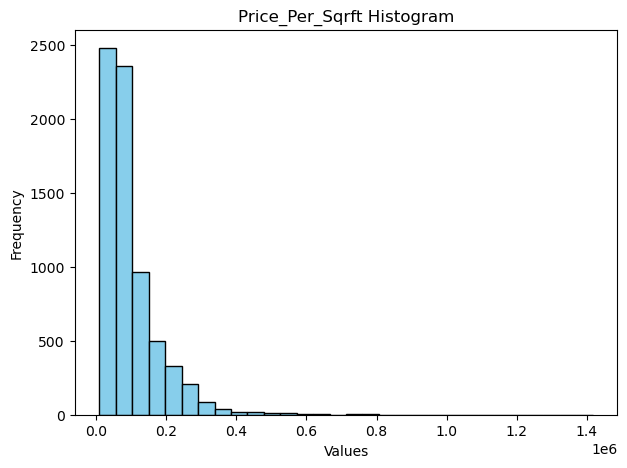

In [168]:
plt.figure(figsize=(7, 5))
plt.hist(df319["Price_Per_Sqrft"], bins=30, color='skyblue', edgecolor='black')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Price_Per_Sqrft Histogram')

plt.show()

In [169]:
df319.Price_Per_Sqrft.value_counts(ascending=False)

Price_Per_Sqrft
50000.000000     69
100000.000000    50
75000.000000     36
60000.000000     32
40000.000000     31
                 ..
17181.818182      1
113157.894737     1
38250.000000      1
135707.142857     1
26294.117647      1
Name: count, Length: 3620, dtype: int64

# 4. Saving the Data (DF4)

## Saving Prepared Data

In [170]:
df4 = df319.copy()

In [171]:
#df4.to_csv("df4_final_preparation.csv", index=False)

In [172]:
#df4.to_excel("df4_final_preparation.xlsx", index=False)

In [173]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7049 entries, 0 to 7048
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Price                            7049 non-null   int64  
 1   Total_Room                       7049 non-null   int64  
 2   Bathroom_Count                   7049 non-null   float64
 3   Net_M2                           7049 non-null   int64  
 4   Number_of_Floors                 7049 non-null   int64  
 5   Floor                            7049 non-null   float64
 6   Furnished_Status                 7049 non-null   int64  
 7   Is_New_Building                  7049 non-null   int64  
 8   Is_Occupied                      7049 non-null   int64  
 9   Is_Swap_Available                7049 non-null   int64  
 10  In_a_Complex                     7049 non-null   int64  
 11  Loan_Eligibility                 7049 non-null   int64  
 12  KonutTipi_Bina      

In [174]:
df4.describe()

,Price,Total_Room,Bathroom_Count,Net_M2,Number_of_Floors,Floor,Furnished_Status,Is_New_Building,Is_Occupied,Is_Swap_Available,...,Heating_Yerden Isıtma-Modern,Tapu_Diger/Riskli,Tapu_Hisseli Mülkiyet,Tapu_Kat İrtifakı,Tapu_Tam Mülkiyet,Building_Type_Encoded,Ground_Risk,District_Encoded,Neighborhood_Encoded,Price_Per_Sqrft
count,7.049000e+03,7049.000000,7049.000000,7049.000000,7049.000000,7049.000000,7049.000000,7049.000000,7049.000000,7049.000000,...,7049.000000,7049.000000,7049.000000,7049.000000,7049.000000,7049.000000,7049.000000,7.049000e+03,7.049000e+03,7.049000e+03
mean,1.126580e+07,3.726912,1.515676,109.490566,6.329125,3.200880,0.052064,0.261030,0.388991,0.130089,...,0.051780,0.024826,0.021705,0.214499,0.701518,0.515109,0.609356,1.126402e+07,1.114548e+07,9.830509e+04
std,1.362004e+07,1.280657,0.738564,48.153391,3.961442,2.982867,0.222172,0.439227,0.487556,0.336426,...,0.221599,0.155606,0.145730,0.410503,0.457625,0.499807,0.257316,7.257989e+06,1.015087e+07,8.318979e+04
min,8.490000e+05,1.000000,1.000000,20.000000,1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.157895,3.201841e+06,9.700000e+05,9.166667e+03
25%,4.400000e+06,3.000000,1.000000,78.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.368421,6.303752e+06,5.339545e+06,4.676471e+04
50%,6.900000e+06,3.000000,1.000000,95.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.526316,8.545338e+06,7.397226e+06,7.250000e+04
75%,1.275000e+07,4.000000,2.000000,130.000000,7.000000,4.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.894737,1.418100e+07,1.317579e+07,1.196667e+05
max,1.900000e+08,21.000000,10.000000,300.000000,25.000000,21.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.947368,3.622555e+07,1.265000e+08,1.416667e+06


In [175]:
#df4[["Price","Total_Room","Bathroom_Count","Net_M2","Number_of_Floors","Floor","Ground_Risk","District","District_Encoded","Neighborhood","Neighborhood_Encoded","Price_Per_Sqrft"]]
df4[["Price","Total_Room","Bathroom_Count","Net_M2","Number_of_Floors","Floor","Ground_Risk","District","Neighborhood","Price_Per_Sqrft"]]

,Price,Total_Room,Bathroom_Count,Net_M2,Number_of_Floors,Floor,Ground_Risk,District,Neighborhood,Price_Per_Sqrft
0,5500000,3,1.0,100,6,1.0,0.926316,Beylikdüzü,Beylikdüzü_Adnan Kahveci Mah.,55000.000000
1,3750000,3,1.0,85,2,2.0,0.842105,Küçükçekmece,Küçükçekmece_Gültepe Mah.,44117.647059
2,23750000,4,2.0,139,6,6.0,0.368421,Kadıköy,Kadıköy_Feneryolu Mah.,170863.309353
3,11500000,3,1.0,90,3,2.0,0.421053,Kadıköy,Kadıköy_Erenköy Mah.,127777.777778
4,3250000,3,1.0,90,5,1.0,0.736842,Sultangazi,Sultangazi_Yunus Emre Mah.,36111.111111
...,...,...,...,...,...,...,...,...,...,...
7044,6250000,4,1.0,140,5,4.0,0.842105,Fatih,Fatih_Seyyid Ömer Mah.,44642.857143
7045,3650000,2,1.0,60,7,1.0,0.894737,Küçükçekmece,Küçükçekmece_Sultan Murat Mah.,60833.333333
7046,10250000,6,2.0,160,6,5.0,0.926316,Avcılar,Avcılar_Denizköşkler Mah.,64062.500000
7047,4470000,6,1.0,170,3,1.0,0.842105,Sancaktepe,Sancaktepe_Kemal Türkler Mah.,26294.117647
